# Comprehensive Latent Class Choice Model Analysis
## Bayesian Linear Membership vs. Gaussian Process Membership Models
### Swissmetro Mode Choice Case Study

This notebook combines two complementary approaches to Latent Class Multinomial Logit (LCCM):
1. **Bayesian LCCM with Linear Membership Model** - Uses logit regression to model class membership
2. **GP-LCCM with Gaussian Process Membership Model** - Uses non-linear GP functions to model class membership with Dirichlet prior regularization

Both models are applied to the Swissmetro dataset to identify heterogeneous traveler preferences.

## 1. Setup and Imports

In [36]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
from pyro.infer import SVI, TraceEnum_ELBO, Trace_ELBO
from pyro.infer.autoguide import AutoNormal
from pyro.optim import ClippedAdam
from pyro.ops.indexing import Vindex
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logsumexp, softmax
from sklearn.model_selection import train_test_split
from pathlib import Path
import math

# Set seeds for reproducibility
np.random.seed(11)
torch.manual_seed(11)
pyro.set_rng_seed(11)

# Set up device (GPU if available)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Using device: cpu


## 2. Data Loading and Preprocessing

In [37]:
# Load data
df = pd.read_csv('swissmetro/swissmetro.dat', sep='\t')
print("Raw data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Filter for valid observations
valid_age = df['AGE'].notna() & (df['AGE'] != 6)
valid_choice = df['CHOICE'] != 0
valid_purpose = df['PURPOSE'] != 9
df = df[valid_age & valid_choice & valid_purpose].copy()

print("\nFiltered data shape:", df.shape)

# Train/Test split by person ID
unique_ids = df["ID"].unique()
train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42, shuffle=True)

train_df = df[df["ID"].isin(train_ids)].copy()
test_df = df[df["ID"].isin(test_ids)].copy()

print(f"Train: {train_df.shape[0]} rows, {train_df['ID'].nunique()} persons")
print(f"Test: {test_df.shape[0]} rows, {test_df['ID'].nunique()} persons")

# Normalize travel time and cost (fit on train, apply to both)
tt_cols = ["TRAIN_TT", "SM_TT", "CAR_TT"]
co_cols = ["TRAIN_CO", "SM_CO", "CAR_CO"]

tt_train_values = train_df[tt_cols].values.reshape(-1)
co_train_values = train_df[co_cols].values.reshape(-1)

tt_mean = tt_train_values.mean()
tt_std = tt_train_values.std()
co_mean = co_train_values.mean()
co_std = co_train_values.std()

for col in tt_cols:
    train_df[col + "_SCALED"] = (train_df[col] - tt_mean) / tt_std
    test_df[col + "_SCALED"] = (test_df[col] - tt_mean) / tt_std

for col in co_cols:
    train_df[col + "_SCALED"] = (train_df[col] - co_mean) / co_std
    test_df[col + "_SCALED"] = (test_df[col] - co_mean) / co_std

print(f"\nNormalization factors:")
print(f"Travel Time: mean={tt_mean:.2f}, std={tt_std:.2f}")
print(f"Travel Cost: mean={co_mean:.2f}, std={co_std:.2f}")

Raw data shape: (10728, 28)

First few rows:
   GROUP  SURVEY  SP  ID  PURPOSE  FIRST  TICKET  WHO  LUGGAGE  AGE  ...  \
0      2       0   1   1        1      0       1    1        0    3  ...   
1      2       0   1   1        1      0       1    1        0    3  ...   
2      2       0   1   1        1      0       1    1        0    3  ...   
3      2       0   1   1        1      0       1    1        0    3  ...   
4      2       0   1   1        1      0       1    1        0    3  ...   

   TRAIN_TT  TRAIN_CO  TRAIN_HE  SM_TT  SM_CO  SM_HE  SM_SEATS  CAR_TT  \
0       112        48       120     63     52     20         0     117   
1       103        48        30     60     49     10         0     117   
2       130        48        60     67     58     30         0     117   
3       103        40        30     63     52     20         0      72   
4       130        36        60     63     42     20         0      90   

   CAR_CO  CHOICE  
0      65       2  
1      84    

## 3. Shared Utility Functions

These functions are used by both the Bayesian LCCM and GP-LCCM approaches.

In [38]:
def create_long_format(df):
    """Convert wide format to long format with availability masking."""
    long_data = []
    obs_id_map = {orig_idx: new_idx for new_idx, orig_idx in enumerate(df.index.unique())}
    
    for idx, row in df.iterrows():
        obs_id_seq = obs_id_map[idx]
        person_id = row['ID']
        
        # Train
        if row['TRAIN_AV'] == 1:
            long_data.append({
                'obs_id': obs_id_seq, 'ID': person_id, 'alt_id': 0,
                'tt': row['TRAIN_TT_SCALED'], 'co': row['TRAIN_CO_SCALED'],
                'choice': 1 if row['CHOICE'] == 1 else 0
            })
        
        # SwissMetro
        if row['SM_AV'] == 1:
            long_data.append({
                'obs_id': obs_id_seq, 'ID': person_id, 'alt_id': 1,
                'tt': row['SM_TT_SCALED'], 'co': row['SM_CO_SCALED'],
                'choice': 1 if row['CHOICE'] == 2 else 0
            })
        
        # Car
        if row['CAR_AV'] == 1:
            long_data.append({
                'obs_id': obs_id_seq, 'ID': person_id, 'alt_id': 2,
                'tt': row['CAR_TT_SCALED'], 'co': row['CAR_CO_SCALED'],
                'choice': 1 if row['CHOICE'] == 3 else 0
            })
    
    long_df = pd.DataFrame(long_data)
    assert (long_df.groupby('obs_id')['choice'].sum() == 1).all()
    return long_df


def recode_membership_variables(person_df):
    """Recode demographic variables for membership model."""
    person_df = person_df.copy()
    
    income_map = {0: 1, 1: 1, 2: 2, 3: 3, 4: 4}
    person_df["INCOME_REC"] = person_df["INCOME"].map(income_map)
    
    luggage_map = {0: 0, 1: 1, 3: 2}
    person_df["LUGGAGE_REC"] = person_df["LUGGAGE"].map(luggage_map)
    
    purpose_map = {1: 1, 5: 1, 2: 2, 6: 2, 3: 3, 7: 3, 4: 4, 8: 4}
    person_df["PURPOSE_REC"] = person_df["PURPOSE"].map(purpose_map)
    
    return person_df


def build_membership_matrix(person_df, include_GA=True, reference_cols=None):
    """Build person-level membership covariate matrix Z."""
    person_df = recode_membership_variables(person_df)
    
    binary_vars = ["MALE", "FIRST"]
    if include_GA:
        binary_vars.append("GA")
    
    Z = person_df[binary_vars].astype(float).copy()
    
    for var in ["AGE", "INCOME_REC", "LUGGAGE_REC", "PURPOSE_REC"]:
        dummies = pd.get_dummies(person_df[var], prefix=var, dtype=float)
        dummies = dummies.iloc[:, 1:]
        Z = pd.concat([Z, dummies], axis=1)
    
    if reference_cols is not None:
        Z = Z.reindex(columns=reference_cols, fill_value=0.0)
    
    return Z


def prepare_lccm_data(long_df, id_col="ID", include_GA=True, reference_Z_cols=None):
    """Prepare data for LCCM models."""
    df = long_df.copy()
    df["obs_id"] = pd.factorize(df["obs_id"])[0]
    df["alt_id"] = df["alt_id"].astype(int)
    
    assert (df.groupby("obs_id")["choice"].sum() == 1).all()
    
    obs_person = df.groupby("obs_id")[id_col].first().reset_index().sort_values("obs_id")
    obs_person["person_idx"] = pd.factorize(obs_person[id_col])[0]
    
    person_obs_id = obs_person["person_idx"].values
    n_persons = obs_person["person_idx"].nunique()
    
    demo_cols = [id_col, "AGE", "MALE", "INCOME", "FIRST", "LUGGAGE", "PURPOSE"]
    if include_GA:
        demo_cols.append("GA")
    
    person_df = df.groupby(id_col, as_index=False).first()[demo_cols].copy()
    person_df["person_idx"] = person_df[id_col].map(
        dict(zip(obs_person[id_col], obs_person["person_idx"]))
    )
    person_df = person_df.sort_values("person_idx").reset_index(drop=True)
    
    Z_df = build_membership_matrix(person_df, include_GA=include_GA, reference_cols=reference_Z_cols)
    
    return {
        "df": df,
        "n_obs": df["obs_id"].nunique(),
        "n_alts": df["alt_id"].nunique(),
        "n_persons": n_persons,
        "tt": df["tt"].values,
        "co": df["co"].values,
        "obs_id": df["obs_id"].values,
        "alt_id": df["alt_id"].values,
        "choice": df["choice"].values,
        "person_obs_id": person_obs_id,
        "person_ids": person_df[id_col].values,
        "Z": Z_df.values.astype(float),
        "Z_cols": Z_df.columns.tolist(),
    }


def to_torch_lccm(data):
    """Convert data dict to torch tensors."""
    return {
        "X": torch.tensor(np.column_stack([data["tt"], data["co"]]), dtype=torch.float32, device=DEVICE),
        "obs_id": torch.tensor(data["obs_id"], dtype=torch.long, device=DEVICE),
        "alt_id": torch.tensor(data["alt_id"], dtype=torch.long, device=DEVICE),
        "choice": torch.tensor(data["choice"], dtype=torch.float32, device=DEVICE),
        "person_obs_id": torch.tensor(data["person_obs_id"], dtype=torch.long, device=DEVICE),
        "Z": torch.tensor(data["Z"], dtype=torch.float32, device=DEVICE),
        "n_obs": data["n_obs"],
        "n_alts": data["n_alts"],
        "n_persons": data["n_persons"],
        "person_ids": data["person_ids"],
        "Z_cols": data["Z_cols"],
    }


# Prepare data for both models
long_df_train = create_long_format(train_df)
long_df_test = create_long_format(test_df)

# Get demographic info
demo_cols = ['ID', 'AGE', 'MALE', 'INCOME', 'FIRST', 'LUGGAGE', 'PURPOSE', 'GA']
person_demo = df[demo_cols].drop_duplicates(subset='ID').copy()

long_df_train = long_df_train.merge(person_demo, on='ID', how='left')
long_df_test = long_df_test.merge(person_demo, on='ID', how='left')

# Prepare data structures
train_data = prepare_lccm_data(long_df_train, id_col="ID", include_GA=True)
test_data = prepare_lccm_data(long_df_test, id_col="ID", include_GA=True, 
                              reference_Z_cols=train_data["Z_cols"])

train_torch = to_torch_lccm(train_data)
test_torch = to_torch_lccm(test_data)

print(f"Data prepared for both models:")
print(f"  Train: {train_data['n_obs']} observations, {train_data['n_persons']} persons")
print(f"  Test: {test_data['n_obs']} observations, {test_data['n_persons']} persons")
print(f"  Membership covariates (Z): {train_data['Z'].shape[1]} features")

Data prepared for both models:
  Train: 8550 observations, 950 persons
  Test: 2142 observations, 238 persons
  Membership covariates (Z): 15 features


## 4. Bayesian LCCM: Linear Membership Model

The Bayesian LCCM uses a **linear logit regression** to model class membership as a function of person-level demographics.

**Model Structure:**
- **Membership model:** $\log \frac{P(k)}{P(K)} = \gamma_k \cdot Z_i$ (multinomial logit)
- **Choice model:** $P(j|k) = \frac{e^{V_{ij,k}}}{\sum_m e^{V_{im,k}}}$ where $V_{ij,k} = \beta_{tt,k} \cdot tt + \beta_{co,k} \cdot co + ASC_{jk}$

In [39]:
def compute_person_class_ll(X, obs_id, alt_id, choice, person_obs_id, beta, asc_raw, 
                            n_obs, n_alts, n_persons, K):
    """Compute person×class likelihood matrix."""
    zeros = torch.zeros(K, 1, dtype=X.dtype, device=X.device)
    asc_full = torch.cat([asc_raw[:, :1], zeros, asc_raw[:, 1:2]], dim=1)
    scen_ll = torch.zeros(n_obs, K, dtype=X.dtype, device=X.device)
    
    for k in range(K):
        V_long = X @ beta[k] + asc_full[k][alt_id]
        V_wide = torch.full((n_obs, n_alts), -1e9, dtype=X.dtype, device=X.device)
        V_wide[obs_id, alt_id] = V_long
        log_denom = torch.logsumexp(V_wide, dim=1)
        chosen_V = V_long[choice == 1]
        scen_ll[:, k] = chosen_V - log_denom
    
    person_class_ll = torch.zeros(n_persons, K, dtype=X.dtype, device=X.device)
    person_class_ll.scatter_add_(0, person_obs_id.unsqueeze(1).expand_as(scen_ll), scen_ll)
    return person_class_ll


def lccm_pyro_model_linear(X, obs_id, alt_id, choice, person_obs_id, Z, n_obs, n_alts,
                          n_persons, K, prior_withconstraints):
    """Bayesian LCCM with linear membership model."""
    n_features = X.shape[1]
    n_Z = Z.shape[1]
    
    # Choice model priors
    if prior_withconstraints:
        beta_raw = pyro.sample("beta_raw", dist.Normal(0.0, 1.0).expand([K, n_features]).to_event(2))
        beta = -torch.nn.functional.softplus(beta_raw)
    else:
        beta = pyro.sample("beta", dist.Normal(0.0, 2.0).expand([K, n_features]).to_event(2))
    
    asc_raw = pyro.sample("asc_raw", dist.Normal(0.0, 2.0).expand([K, n_alts - 1]).to_event(2))
    
    # Membership model: linear logit
    gamma = pyro.sample("gamma", dist.Normal(0.0, 2.0).expand([K - 1, n_Z + 1]).to_event(2))
    
    Z_aug = torch.cat([torch.ones(n_persons, 1, dtype=Z.dtype, device=Z.device), Z], dim=1)
    eta_nonbase = Z_aug @ gamma.T
    eta = torch.cat([eta_nonbase, torch.zeros(n_persons, 1, dtype=Z.dtype, device=Z.device)], dim=1)
    log_class_probs = torch.log_softmax(eta, dim=1)
    
    # Likelihood
    person_class_ll = compute_person_class_ll(X, obs_id, alt_id, choice, person_obs_id,
                                              beta, asc_raw, n_obs, n_alts, n_persons, K)
    
    # Explicit latent class
    with pyro.plate("persons", n_persons, dim=-1):
        q = pyro.sample("q", dist.Categorical(logits=log_class_probs), infer={"enumerate": "parallel"})
        person_idx = torch.arange(n_persons, device=X.device)
        ll_q = Vindex(person_class_ll)[person_idx, q]
        pyro.factor("choice_loglik", ll_q)


def fit_bayesian_lccm(train_torch, test_torch, train_data, test_data, K, prior_withconstraints=True, n_steps=3000):
    """Fit Bayesian LCCM with linear membership model."""
    print(f"\n{'='*60}")
    print(f"Fitting Bayesian LCCM (K={K}, constraints={prior_withconstraints})")
    print(f"{'='*60}")
    
    pyro.clear_param_store()
    pyro.set_rng_seed(42 + K)
    
    guide = AutoNormal(poutine.block(lccm_pyro_model_linear, hide=["q"]))
    optimizer = ClippedAdam({"lr": 0.03, "lrd": 0.9995})
    svi = SVI(lccm_pyro_model_linear, guide, optimizer, loss=TraceEnum_ELBO(max_plate_nesting=1))
    
    losses = []
    for step in range(n_steps):
        loss = svi.step(
            train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
            train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
            train_torch["n_alts"], train_torch["n_persons"], K, prior_withconstraints
        )
        losses.append(loss)
        if step % 500 == 0 or step == n_steps - 1:
            print(f"  Step {step:4d} | ELBO loss = {loss:,.2f}")
    
    posterior = guide.median(
        train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
        train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
        train_torch["n_alts"], train_torch["n_persons"], K, prior_withconstraints
    )
    
    if prior_withconstraints:
        beta = -torch.nn.functional.softplus(posterior["beta_raw"])
    else:
        beta = posterior["beta"]
    
    asc_raw = posterior["asc_raw"]
    gamma = posterior["gamma"]
    
    # Compute class shares
    Z_train = train_torch["Z"]
    Z_aug = torch.cat([torch.ones(train_data["n_persons"], 1, dtype=Z_train.dtype, device=Z_train.device), Z_train], dim=1)
    eta_nonbase = Z_aug @ gamma.T
    eta = torch.cat([eta_nonbase, torch.zeros(train_data["n_persons"], 1, dtype=Z_train.dtype, device=Z_train.device)], dim=1)
    class_probs = torch.softmax(eta, dim=1)
    class_share = class_probs.mean(dim=0).detach().numpy()
    
    print(f"\nClass shares: {[f'{s:.3f}' for s in class_share]}")
    
    return {
        "model_type": "Bayesian-Linear",
        "K": K,
        "posterior": posterior,
        "beta": beta.detach().cpu().numpy(),
        "asc_raw": asc_raw.detach().cpu().numpy(),
        "gamma": gamma.detach().cpu().numpy(),
        "class_share": class_share,
        "losses": losses,
    }


# Fit models with different K values
bayesian_results = {}
for k in [1, 2, 3, 4, 5, 6, 7]:
    bayesian_results[k] = fit_bayesian_lccm(train_torch, test_torch, train_data, test_data, 
                                             k, prior_withconstraints=True, n_steps=1000)


Fitting Bayesian LCCM (K=1, constraints=True)
  Step    0 | ELBO loss = 8,537.30
  Step  500 | ELBO loss = 7,257.27
  Step  999 | ELBO loss = 7,254.30

Class shares: ['1.000']

Fitting Bayesian LCCM (K=2, constraints=True)
  Step    0 | ELBO loss = 8,396.01
  Step  500 | ELBO loss = 6,022.34
  Step  999 | ELBO loss = 5,941.20

Class shares: ['0.358', '0.642']

Fitting Bayesian LCCM (K=3, constraints=True)
  Step    0 | ELBO loss = 8,280.36
  Step  500 | ELBO loss = 5,569.04
  Step  999 | ELBO loss = 5,555.29

Class shares: ['0.211', '0.478', '0.310']

Fitting Bayesian LCCM (K=4, constraints=True)
  Step    0 | ELBO loss = 8,524.94
  Step  500 | ELBO loss = 5,288.28
  Step  999 | ELBO loss = 5,290.41

Class shares: ['0.504', '0.124', '0.221', '0.151']

Fitting Bayesian LCCM (K=5, constraints=True)
  Step    0 | ELBO loss = 8,588.78
  Step  500 | ELBO loss = 5,224.19
  Step  999 | ELBO loss = 5,192.41

Class shares: ['0.093', '0.184', '0.176', '0.400', '0.147']

Fitting Bayesian LCCM (K

## 5. GP-LCCM: Gaussian Process Membership Model

The GP-LCCM uses Gaussian Processes to model class membership as a non-linear function of person-level demographics. A Dirichlet prior is added to encourage balanced class representations.

**Key Features:**
- Non-linear membership model: $f_k(Z_i) \sim GP(\mathbf{0}, K_{\theta}(Z, Z))$ with Matérn 3/2 kernel
- Dirichlet prior: $P_k \sim \text{Dirichlet}(\alpha k)$ where $\alpha=0.5$ encourages all classes to be represented
- Regularization: Empirical class shares align with the Dirichlet prior

In [40]:
def matern32_kernel(X1, X2, kappa, lengthscale):
    """Matérn 3/2 kernel for GP."""
    dist_matrix = torch.cdist(X1, X2)
    scaled = np.sqrt(3.0) * dist_matrix / lengthscale
    return (kappa**2) * (1.0 + scaled) * torch.exp(-scaled)


def lccm_pyro_model_gp(X, obs_id, alt_id, choice, person_obs_id, Z, n_obs, n_alts,
                       n_persons, K, prior_withconstraints):
    """Bayesian LCCM with GP-based membership model"""
    n_features = X.shape[1]
    
    # GP hyperparameters
    kappa = pyro.sample("kappa", dist.LogNormal(0.0, 0.5).expand([K]).to_event(1))
    lengthscale = pyro.sample("lengthscale", dist.LogNormal(0.0, 0.5).expand([K]).to_event(1))
    
    kappa = kappa.to(device=Z.device, dtype=Z.dtype)
    lengthscale = lengthscale.to(device=Z.device, dtype=Z.dtype)
    
    # GP latent functions
    f_list = []
    eye = torch.eye(n_persons, dtype=Z.dtype, device=Z.device)
    for k in range(K):
        cov = matern32_kernel(Z, Z, kappa[k], lengthscale[k]) + 1e-4 * eye
        f_list.append(pyro.sample(f"gp_latent_{k}", dist.MultivariateNormal(
            torch.zeros(n_persons, dtype=Z.dtype, device=Z.device), covariance_matrix=cov)))
    
    f = torch.stack(f_list, dim=1)
    
    # Class intercepts to break symmetry
    class_intercept_loc = torch.linspace(-0.4, 0.4, K, dtype=Z.dtype, device=Z.device)
    class_intercept = pyro.sample("class_intercept", dist.Normal(class_intercept_loc, 0.3).to_event(1))
    class_intercept = class_intercept.to(device=Z.device, dtype=Z.dtype)
    
    log_class_probs = torch.log_softmax(f + class_intercept.unsqueeze(0), dim=1)
    
    # Dirichlet prior on class shares
    class_share = pyro.sample("class_share",
        dist.Dirichlet(torch.ones(K, dtype=Z.dtype, device=Z.device) * 0.5))
    
    # Choice model
    if prior_withconstraints:
        beta_raw = pyro.sample("beta_raw", dist.Normal(0.0, 1.0).expand([K, n_features]).to_event(2))
        beta = -torch.nn.functional.softplus(beta_raw)
    else:
        beta = pyro.sample("beta", dist.Normal(0.0, 2.0).expand([K, n_features]).to_event(2))
    
    asc_raw = pyro.sample("asc_raw", dist.Normal(0.0, 1.0).expand([K, n_alts - 1]).to_event(2))
    zeros = torch.zeros(K, 1, dtype=X.dtype, device=X.device)
    asc_full = torch.cat([asc_raw[:, :1], zeros, asc_raw[:, 1:2]], dim=1)
    
    # Likelihood
    scen_ll = torch.zeros(n_obs, K, dtype=X.dtype, device=X.device)
    for k in range(K):
        v_k = X @ beta[k] + asc_full[k][alt_id]
        v_wide_k = torch.full((n_obs, n_alts), -1e9, dtype=X.dtype, device=X.device)
        v_wide_k[obs_id, alt_id] = v_k
        scen_ll[:, k] = dist.Categorical(logits=v_wide_k).log_prob(
            torch.zeros(n_obs, dtype=torch.long).scatter_(0, obs_id[choice == 1], alt_id[choice == 1]))
    
    person_class_ll = torch.zeros(n_persons, K, dtype=X.dtype, device=X.device)
    person_class_ll.scatter_add_(0, person_obs_id.unsqueeze(1).expand_as(scen_ll), scen_ll)
    
    log_marginal = torch.logsumexp(log_class_probs + person_class_ll, dim=1)
    
    # Regularization: empirical class shares align with Dirichlet prior
    empirical_class_shares = torch.softmax(log_class_probs / 0.5, dim=1).mean(dim=0)
    pyro.factor("class_share_regularization", 
                dist.Dirichlet(class_share * 100).log_prob(empirical_class_shares))
    
    pyro.factor("loglik", log_marginal.sum())


def fit_gp_lccm(train_torch, test_torch, train_data, test_data, K, prior_withconstraints=True, n_steps = 3000):
    """Fit GP-LCCM"""
    print(f"\n{'='*60}")
    print(f"Fitting GP-LCCM (K={K}, constraints={prior_withconstraints})")
    print(f"{'='*60}")
    
    pyro.clear_param_store()
    pyro.set_rng_seed(42 + K)
    
    guide = AutoNormal(lccm_pyro_model_gp)
    optimizer = ClippedAdam({"lr": 0.03, "lrd": 0.9995})
    svi = SVI(lccm_pyro_model_gp, guide, optimizer, loss=Trace_ELBO())
    
    losses = []
    for step in range(n_steps):
        loss = svi.step(
            train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
            train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
            train_torch["n_alts"], train_torch["n_persons"], K, prior_withconstraints
        )
        losses.append(loss)
        if step % 500 == 0 or step == n_steps - 1:
            print(f"  Step {step:4d} | ELBO loss = {loss:,.2f}")
    
    posterior = guide.median(
        train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
        train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
        train_torch["n_alts"], train_torch["n_persons"], K, prior_withconstraints
    )
    
    if prior_withconstraints:
        beta = -torch.nn.functional.softplus(posterior["beta_raw"])
    else:
        beta = posterior["beta"]
    
    asc_raw = posterior["asc_raw"]
    class_share = posterior.get("class_share", None)
    
    if class_share is not None:
        class_share = class_share.detach().cpu().numpy()
    else:
        # Fallback: compute from GP latents
        f = torch.stack([posterior[f"gp_latent_{k}"] for k in range(K)], dim=1)
        class_intercept = posterior["class_intercept"]
        log_probs = torch.log_softmax(f + class_intercept.unsqueeze(0), dim=1)
        class_share = torch.softmax(log_probs, dim=1).mean(dim=0).detach().cpu().numpy()
    
    print(f"\nClass shares: {[f'{s:.3f}' for s in class_share]}")
    
    return {
        "model_type": "GP",
        "K": K,
        "posterior": posterior,
        "beta": beta.detach().cpu().numpy(),
        "asc_raw": asc_raw.detach().cpu().numpy(),
        "class_share": class_share,
        "losses": losses,
    }


# Fit GP-LCCM models
gp_results = {}
for k in [1, 2, 3, 4, 5]:
    gp_results[k] = fit_gp_lccm(train_torch, test_torch, train_data, test_data,
                                 k, prior_withconstraints=True, n_steps=1000)


Fitting GP-LCCM (K=1, constraints=True)
  Step    0 | ELBO loss = 36,692.37
  Step  500 | ELBO loss = 8,220.40
  Step  999 | ELBO loss = 8,050.66

Class shares: ['1.000']

Fitting GP-LCCM (K=2, constraints=True)
  Step    0 | ELBO loss = 69,044.26
  Step  500 | ELBO loss = 8,080.97
  Step  999 | ELBO loss = 7,485.12

Class shares: ['0.387', '0.613']

Fitting GP-LCCM (K=3, constraints=True)
  Step    0 | ELBO loss = 94,926.96
  Step  500 | ELBO loss = 8,257.94
  Step  999 | ELBO loss = 7,597.16

Class shares: ['0.064', '0.312', '0.624']

Fitting GP-LCCM (K=4, constraints=True)
  Step    0 | ELBO loss = 123,121.68
  Step  500 | ELBO loss = 9,285.64
  Step  999 | ELBO loss = 8,221.93

Class shares: ['0.232', '0.558', '0.079', '0.131']

Fitting GP-LCCM (K=5, constraints=True)
  Step    0 | ELBO loss = 156,931.04
  Step  500 | ELBO loss = 9,736.60
  Step  999 | ELBO loss = 8,820.73

Class shares: ['0.045', '0.348', '0.027', '0.246', '0.334']


In [41]:
## GP-LCCM for classes 6 and 7

for k in [6, 7]:
    gp_results[k] = fit_gp_lccm(train_torch, test_torch, train_data, test_data,
                                 k, prior_withconstraints=True, n_steps=1000)


Fitting GP-LCCM (K=6, constraints=True)
  Step    0 | ELBO loss = 181,199.36
  Step  500 | ELBO loss = 10,784.74
  Step  999 | ELBO loss = 9,657.50

Class shares: ['0.058', '0.333', '0.184', '0.027', '0.248', '0.149']

Fitting GP-LCCM (K=7, constraints=True)
  Step    0 | ELBO loss = 211,005.48
  Step  500 | ELBO loss = 11,623.86
  Step  999 | ELBO loss = 10,046.29

Class shares: ['0.040', '0.020', '0.338', '0.053', '0.172', '0.231', '0.145']


In [47]:
# Posterior mean/std for class profiles (Bayesian K=6, GP K=7)
from pyro.infer import Predictive


def fit_bayesian_samples(train_torch, K, n_steps=1000, num_samples=200):
    pyro.clear_param_store()
    pyro.set_rng_seed(42 + K)
    guide = AutoNormal(poutine.block(lccm_pyro_model_linear, hide=["q"]))
    optimizer = ClippedAdam({"lr": 0.03, "lrd": 0.9995})
    svi = SVI(lccm_pyro_model_linear, guide, optimizer, loss=TraceEnum_ELBO(max_plate_nesting=1))
    for step in range(n_steps):
        svi.step(
            train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
            train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
            train_torch["n_alts"], train_torch["n_persons"], K, True
        )
    predictive = Predictive(
        lccm_pyro_model_linear,
        guide=guide,
        num_samples=num_samples,
        return_sites=("beta_raw", "beta", "asc_raw", "gamma"),
    )
    return predictive(
        train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
        train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
        train_torch["n_alts"], train_torch["n_persons"], K, True
    )


def fit_gp_samples(train_torch, K, n_steps=1000, num_samples=200):
    pyro.clear_param_store()
    pyro.set_rng_seed(42 + K)
    guide = AutoNormal(lccm_pyro_model_gp)
    optimizer = ClippedAdam({"lr": 0.03, "lrd": 0.9995})
    svi = SVI(lccm_pyro_model_gp, guide, optimizer, loss=Trace_ELBO())
    for step in range(n_steps):
        svi.step(
            train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
            train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
            train_torch["n_alts"], train_torch["n_persons"], K, True
        )
    return_sites = ["beta_raw", "beta", "asc_raw", "class_intercept"]
    return_sites += [f"gp_latent_{k}" for k in range(K)]
    predictive = Predictive(
        lccm_pyro_model_gp,
        guide=guide,
        num_samples=num_samples,
        return_sites=tuple(return_sites),
    )
    return predictive(
        train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
        train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
        train_torch["n_alts"], train_torch["n_persons"], K, True
    )


def squeeze_samples(tensor):
    return tensor.squeeze()


def profile_stats_from_samples(samples, K, tt_std, co_std, n_alts, Z_train, model_type):
    if "beta_raw" in samples:
        beta_raw = squeeze_samples(samples["beta_raw"])
        beta = -torch.nn.functional.softplus(beta_raw)
    else:
        beta = squeeze_samples(samples["beta"])
    asc_raw = squeeze_samples(samples["asc_raw"])
    if model_type == "Bayesian":
        gamma = squeeze_samples(samples["gamma"])
        Z_aug = torch.cat([
            torch.ones(Z_train.shape[0], 1, dtype=Z_train.dtype, device=Z_train.device),
            Z_train,
        ], dim=1)
        eta_nonbase = torch.einsum("nz,skz->snk", Z_aug, gamma)
        zeros = torch.zeros(eta_nonbase.shape[0], eta_nonbase.shape[1], 1, device=Z_train.device, dtype=Z_train.dtype)
        eta = torch.cat([eta_nonbase, zeros], dim=2)
        class_probs = torch.softmax(eta, dim=2)
        class_share = class_probs.mean(dim=1)
    else:
        class_intercept = squeeze_samples(samples["class_intercept"])
        f = torch.stack([squeeze_samples(samples[f"gp_latent_{k}"]) for k in range(K)], dim=2)
        logits = f + class_intercept.unsqueeze(1)
        class_probs = torch.softmax(logits, dim=2)
        class_share = class_probs.mean(dim=1)
    if asc_raw.shape[2] > 1:
        asc_train = asc_raw[:, :, 0]
        asc_car = asc_raw[:, :, 1]
    else:
        asc_train = torch.zeros(beta.shape[0], K, device=beta.device, dtype=beta.dtype)
        asc_car = torch.zeros(beta.shape[0], K, device=beta.device, dtype=beta.dtype)
    asc_swissmetro = torch.zeros(beta.shape[0], K, device=beta.device, dtype=beta.dtype)
    travel_time = beta[:, :, 0]
    travel_cost = beta[:, :, 1]
    vot = (travel_time * tt_std) / (travel_cost * co_std) * 60.0
    profile = torch.stack([
        asc_train,
        asc_swissmetro,
        asc_car,
        travel_time,
        travel_cost,
        class_share,
        vot,
    ], dim=2)
    mean = profile.mean(dim=0).detach().cpu().numpy()
    std = profile.std(dim=0).detach().cpu().numpy()
    metrics = [
        "ASC (Train)",
        "ASC (SwissMetro)",
        "ASC (Car)",
        "Travel Time Coeff",
        "Travel Cost Coeff",
        "Class Share",
        "VOT (CHF/hour)",
    ]
    columns = [f"Class {k + 1}" for k in range(K)]
    mean_df = pd.DataFrame(mean.T, index=metrics, columns=columns)
    std_df = pd.DataFrame(std.T, index=metrics, columns=columns)
    return mean_df, std_df


profile_stats_dir = Path("combined_results/profile_stats")
profile_stats_dir.mkdir(parents=True, exist_ok=True)


n_alts = train_torch["n_alts"]
Z_train = train_torch["Z"]


bayesian_dir = profile_stats_dir / "Bayesian-Linear"
gp_dir = profile_stats_dir / "GP-LCCM"
bayesian_dir.mkdir(parents=True, exist_ok=True)
gp_dir.mkdir(parents=True, exist_ok=True)


K_bayesian = 7
samples_b = fit_bayesian_samples(train_torch, K_bayesian, n_steps=1000, num_samples=200)
mean_b, std_b = profile_stats_from_samples(samples_b, K_bayesian, tt_std, co_std, n_alts, Z_train, "Bayesian")
mean_b.to_csv(bayesian_dir / f"class_profile_mean_K{K_bayesian}.csv")
std_b.to_csv(bayesian_dir / f"class_profile_std_K{K_bayesian}.csv")
print(f"Bayesian K={K_bayesian} mean:")
display(mean_b)
print(f"Bayesian K={K_bayesian} std:")
display(std_b)


K_gp = 7
samples_g = fit_gp_samples(train_torch, K_gp, n_steps=1000, num_samples=200)
mean_g, std_g = profile_stats_from_samples(samples_g, K_gp, tt_std, co_std, n_alts, Z_train, "GP")
mean_g.to_csv(gp_dir / f"class_profile_mean_K{K_gp}.csv")
std_g.to_csv(gp_dir / f"class_profile_std_K{K_gp}.csv")
print(f"GP K={K_gp} mean:")
display(mean_g)
print(f"GP K={K_gp} std:")
display(std_g)


print(f"Saved profile stats to: {profile_stats_dir}")

Bayesian K=7 mean:


,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7
ASC (Train),-1.512452,0.486354,2.094274,-1.274026,-0.942708,-0.841441,0.266464
ASC (SwissMetro),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ASC (Car),-2.143642,0.230398,-0.762490,3.776921,1.202062,-8.520844,-1.010175
Travel Time Coeff,-3.672246,-0.654086,-0.073511,-1.906184,-2.693728,-0.588245,-1.063935
Travel Cost Coeff,-0.063128,-3.310320,-0.401200,-3.000377,-10.002798,-1.248053,-1.007547
Class Share,0.264494,0.076165,0.043056,0.132998,0.368672,0.110340,0.004274
VOT (CHF/hour),338.272308,1.013401,0.945799,3.342878,1.301443,2.274841,5.295405


Bayesian K=7 std:


,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7
ASC (Train),0.193325,0.142772,0.185615,0.558569,0.130486,0.098445,0.583394
ASC (SwissMetro),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ASC (Car),0.140683,0.141583,0.304525,0.122842,0.051594,0.500381,0.642802
Travel Time Coeff,0.235770,0.087030,0.036798,0.071388,0.079357,0.136060,0.469034
Travel Cost Coeff,0.028379,0.795218,0.113394,0.818202,0.723265,0.078786,0.203082
Class Share,0.044844,0.028085,0.016341,0.032731,0.049811,0.030752,0.000493
VOT (CHF/hour),155.798737,0.314842,0.567092,1.183565,0.099934,0.545135,2.742985


GP K=7 mean:


,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7
ASC (Train),1.051612,0.922171,-0.661673,-0.701256,-0.038557,-0.850883,-1.139219
ASC (SwissMetro),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ASC (Car),-3.948221,0.203553,0.950455,4.138601,2.946884,-3.221607,-0.118015
Travel Time Coeff,-1.114021,-0.063817,-1.449329,-1.780847,-5.083410,-3.958462,-3.926706
Travel Cost Coeff,-0.423440,-0.256892,-8.793376,-1.811247,-4.002600,-0.139376,-1.917483
Class Share,0.085309,0.055258,0.234264,0.093061,0.164713,0.213580,0.153814
VOT (CHF/hour),13.210692,1.367537,0.796277,5.518029,6.258363,155.974167,10.399971


GP K=7 std:


,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7
ASC (Train),0.145492,0.186961,0.111479,0.477049,0.403335,0.181992,0.229608
ASC (SwissMetro),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ASC (Car),0.402342,0.154284,0.080199,0.177622,0.147656,0.236521,0.153333
Travel Time Coeff,0.161341,0.025595,0.060204,0.108392,0.179147,0.263713,0.253159
Travel Cost Coeff,0.081853,0.094444,0.600047,0.665735,0.615835,0.052447,0.410297
Class Share,0.007940,0.007268,0.014644,0.009756,0.012477,0.012919,0.014556
VOT (CHF/hour),3.660992,0.749958,0.064652,2.618090,1.034164,59.660137,2.906667


Saved profile stats to: combined_results/profile_stats


## 6. Visualizations

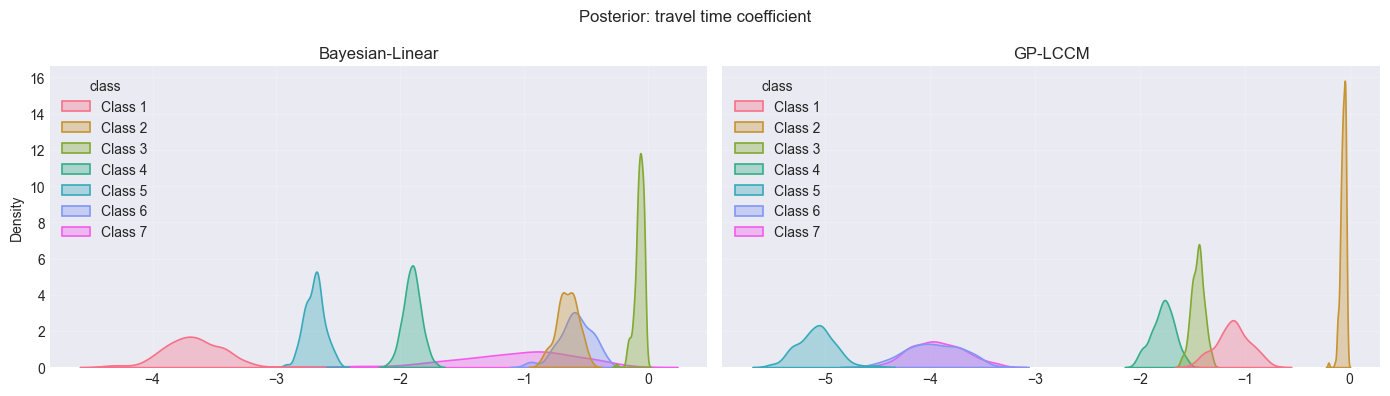

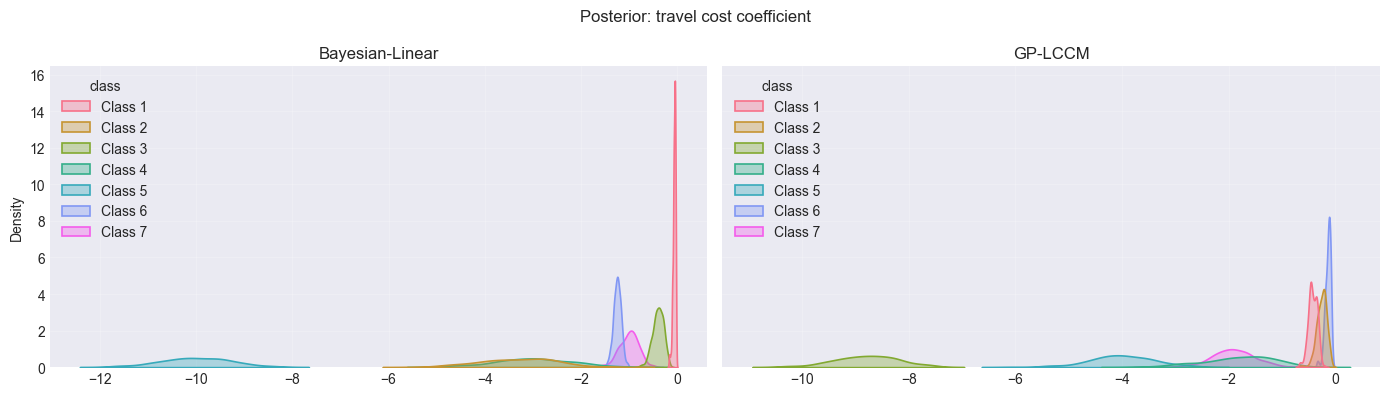

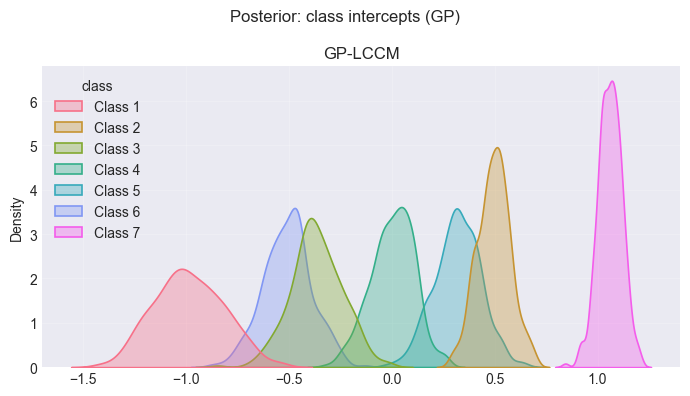

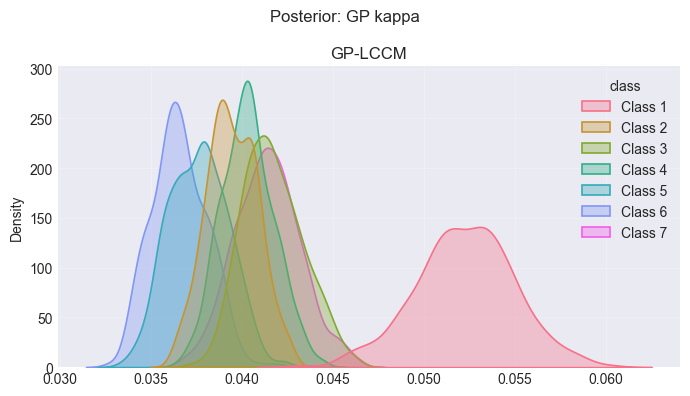

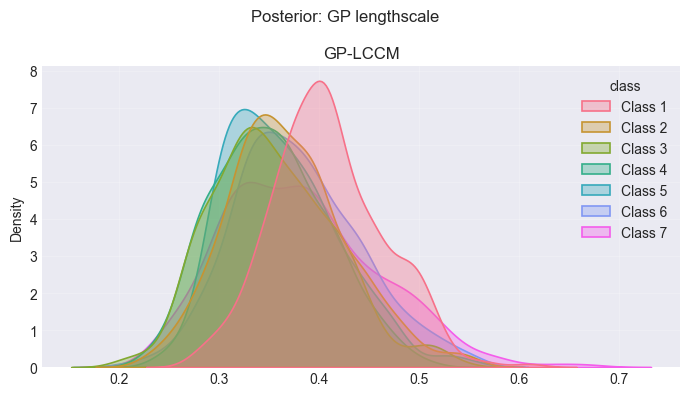

Saved figures to: combined_results/figures


In [50]:
# Posterior visualization: overlapped KDEs with transparency
def fit_gp_samples_with_hypers(train_torch, K, n_steps=1000, num_samples=200):
    pyro.clear_param_store()
    pyro.set_rng_seed(123 + K)
    guide = AutoNormal(lccm_pyro_model_gp)
    optimizer = ClippedAdam({"lr": 0.03, "lrd": 0.9995})
    svi = SVI(lccm_pyro_model_gp, guide, optimizer, loss=Trace_ELBO())
    for step in range(n_steps):
        svi.step(
            train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
            train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
            train_torch["n_alts"], train_torch["n_persons"], K, True
        )
    return_sites = ("beta_raw", "beta", "class_intercept", "kappa", "lengthscale")
    predictive = Predictive(
        lccm_pyro_model_gp,
        guide=guide,
        num_samples=num_samples,
        return_sites=return_sites,
    )
    return predictive(
        train_torch["X"], train_torch["obs_id"], train_torch["alt_id"], train_torch["choice"],
        train_torch["person_obs_id"], train_torch["Z"], train_torch["n_obs"],
        train_torch["n_alts"], train_torch["n_persons"], K, True
    )


def _beta_from_samples(samples):
    if "beta_raw" in samples:
        beta_raw = squeeze_samples(samples["beta_raw"])
        return -torch.nn.functional.softplus(beta_raw)
    return squeeze_samples(samples["beta"])


def build_coef_df(samples, model_name, coef_index, label):
    beta = _beta_from_samples(samples)
    beta = squeeze_samples(beta)
    k_count = beta.shape[1]
    rows = []
    for k_idx in range(k_count):
        values = beta[:, k_idx, coef_index].detach().cpu().numpy()
        rows.append(pd.DataFrame({
            "value": values,
            "class": f"Class {k_idx + 1}",
            "model": model_name,
            "param": label,
        }))
    return pd.concat(rows, ignore_index=True)


def build_param_df(samples, model_name, param_name, label):
    tensor = squeeze_samples(samples[param_name])
    k_count = tensor.shape[1]
    rows = []
    for k_idx in range(k_count):
        values = tensor[:, k_idx].detach().cpu().numpy()
        rows.append(pd.DataFrame({
            "value": values,
            "class": f"Class {k_idx + 1}",
            "model": model_name,
            "param": label,
        }))
    return pd.concat(rows, ignore_index=True)


def _slugify_title(title):
    return "_".join(title.lower().replace("-", " ").replace(":", "").split())


def overlap_kde_plot(df, title, bw_adjust=0.9, alpha=0.35, output_dir=None):
    models = df["model"].unique().tolist()
    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 4), sharey=True)
    if n_models == 1:
        axes = [axes]
    for ax, model_name in zip(axes, models):
        data = df[df["model"] == model_name]
        sns.kdeplot(
            data=data,
            x="value",
            hue="class",
            fill=True,
            alpha=alpha,
            linewidth=1.2,
            bw_adjust=bw_adjust,
            common_norm=False,
            ax=ax,
        )
        ax.set_title(model_name)
        ax.set_xlabel("")
        ax.set_ylabel("Density")
        ax.grid(True, alpha=0.2)
    fig.suptitle(title)
    plt.tight_layout()
    if output_dir is not None:
        output_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{_slugify_title(title)}.png"
        fig.savefig(output_dir / filename, dpi=200, bbox_inches="tight")
    plt.show()


figure_dir = Path("combined_results/figures")
figure_dir.mkdir(parents=True, exist_ok=True)


samples_g_h = fit_gp_samples_with_hypers(train_torch, K_gp, n_steps=1000, num_samples=300)


df_tt = pd.concat([
    build_coef_df(samples_b, "Bayesian-Linear", 0, "Travel time"),
    build_coef_df(samples_g, "GP-LCCM", 0, "Travel time"),
], ignore_index=True)


df_co = pd.concat([
    build_coef_df(samples_b, "Bayesian-Linear", 1, "Travel cost"),
    build_coef_df(samples_g, "GP-LCCM", 1, "Travel cost"),
], ignore_index=True)


df_intercepts = build_param_df(samples_g_h, "GP-LCCM", "class_intercept", "Class intercept")
df_kappa = build_param_df(samples_g_h, "GP-LCCM", "kappa", "GP kappa")
df_lengthscale = build_param_df(samples_g_h, "GP-LCCM", "lengthscale", "GP lengthscale")


overlap_kde_plot(df_tt, "Posterior: travel time coefficient", output_dir=figure_dir)
overlap_kde_plot(df_co, "Posterior: travel cost coefficient", output_dir=figure_dir)
overlap_kde_plot(df_intercepts, "Posterior: class intercepts (GP)", output_dir=figure_dir)
overlap_kde_plot(df_kappa, "Posterior: GP kappa", output_dir=figure_dir)
overlap_kde_plot(df_lengthscale, "Posterior: GP lengthscale", output_dir=figure_dir)


print(f"Saved figures to: {figure_dir}")

## 7. Model Comparison and Results


CLASS PROFILES COMPARISON

--- K=2 Classes ---

Bayesian LCCM (Linear Membership):
                   Class 1  Class 2
ASC (Train)        -0.8780  -1.5199
ASC (SwissMetro)    0.0000   0.0000
ASC (Car)          -3.1683   0.6911
Travel Time Coeff  -0.3154  -1.4010
Travel Cost Coeff  -0.2859 -10.6214
Class Share         0.3575   0.6425
VOT (CHF/hour)      5.3035   0.6342

GP-LCCM:
                   Class 1  Class 2
ASC (Train)        -0.0432  -1.1070
ASC (SwissMetro)    0.0000   0.0000
ASC (Car)          -1.8587   0.8412
Travel Time Coeff  -2.1837  -0.9301
Travel Cost Coeff  -0.1429  -7.7178
Class Share         0.3874   0.6126
VOT (CHF/hour)     73.5013   0.5794

--- K=3 Classes ---

Bayesian LCCM (Linear Membership):
                   Class 1  Class 2  Class 3
ASC (Train)        -0.1198  -0.8847  -1.7552
ASC (SwissMetro)    0.0000   0.0000   0.0000
ASC (Car)          -2.2748   1.3801  -1.1774
Travel Time Coeff  -0.0753  -1.5364  -3.0913
Travel Cost Coeff  -0.0380  -8.6594  -1.5778
Cla

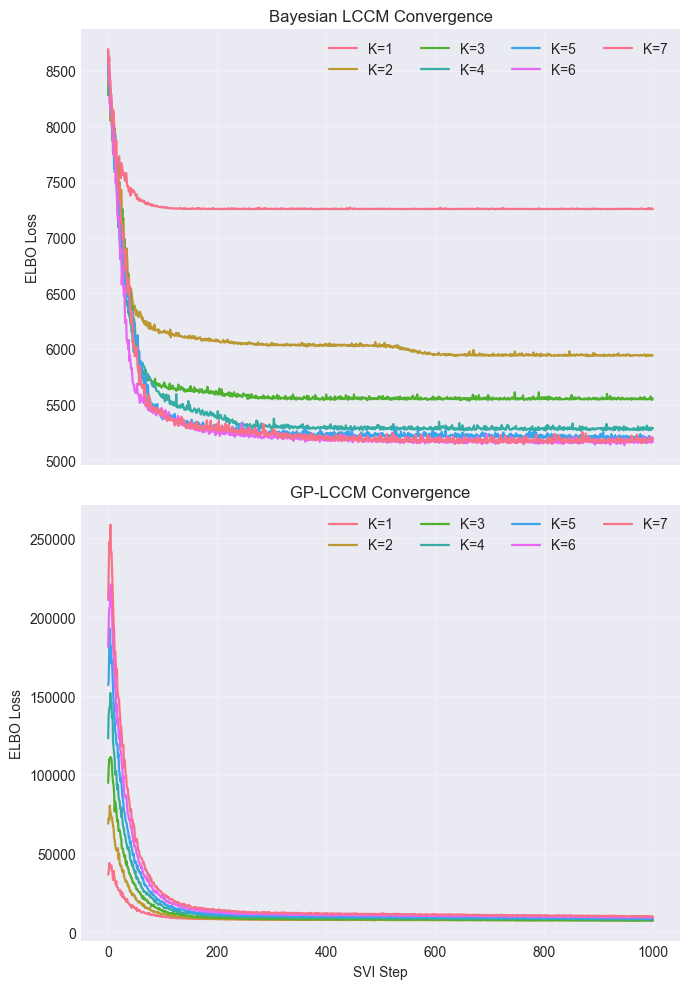

In [52]:
def class_profile_table(beta, asc_raw, class_share):
    """Build attribute-by-class comparison table."""
    K = beta.shape[0]
    columns = [f"Class {k + 1}" for k in range(K)]
    
    asc_train = asc_raw[:, 0] if asc_raw.shape[1] > 0 else np.zeros(K)
    asc_swissmetro = np.zeros(K)
    asc_car = asc_raw[:, 1] if asc_raw.shape[1] > 1 else np.zeros(K)
    travel_time = beta[:, 0]
    travel_cost = beta[:, 1]
    
    # Value of time (CHF/hour) = (dU/dtt normalized) / (dU/dco normalized)
    vot = (travel_time * tt_std) / (travel_cost * co_std) * 60  # Convert to per hour
    
    profile = pd.DataFrame({
        col: [
            asc_train[i],
            asc_swissmetro[i],
            asc_car[i],
            travel_time[i],
            travel_cost[i],
            class_share[i],
            vot[i],
        ]
        for i, col in enumerate(columns)
    }, index=[
        "ASC (Train)",
        "ASC (SwissMetro)",
        "ASC (Car)",
        "Travel Time Coeff",
        "Travel Cost Coeff",
        "Class Share",
        "VOT (CHF/hour)",
    ])
    
    return profile


# Create comparison table
print("\n" + "="*80)
print("CLASS PROFILES COMPARISON")
print("="*80)


for k in [2, 3, 4, 5, 6, 7]:
    print(f"\n--- K={k} Classes ---")
    
    if k in bayesian_results:
        print("\nBayesian LCCM (Linear Membership):")
        profile_b = class_profile_table(bayesian_results[k]["beta"], 
                                        bayesian_results[k]["asc_raw"],
                                        bayesian_results[k]["class_share"])
        print(profile_b.round(4))
    
    if k in gp_results:
        print("\nGP-LCCM:")
        profile_gp = class_profile_table(gp_results[k]["beta"],
                                         gp_results[k]["asc_raw"],
                                         gp_results[k]["class_share"])
        print(profile_gp.round(4))


# Plot convergence: Bayesian curves stacked over GP-LCCM curves
k_values = [1, 2, 3, 4, 5, 6, 7]

fig, axes = plt.subplots(2, 1, figsize=(7, 10), sharex=True)
ax_bayes, ax_gp = axes

for k in k_values:
    if k in bayesian_results:
        ax_bayes.plot(
            bayesian_results[k]["losses"],
            label=f"K={k}",
            linewidth=1.6
        )

for k in k_values:
    if k in gp_results:
        ax_gp.plot(
            gp_results[k]["losses"],
            label=f"K={k}",
            linewidth=1.6
        )

ax_bayes.set_title("Bayesian LCCM Convergence")
ax_bayes.set_ylabel("ELBO Loss")
ax_bayes.legend(loc='best', ncol=4)
ax_bayes.grid(True, alpha=0.3)

ax_gp.set_title("GP-LCCM Convergence")
ax_gp.set_xlabel("SVI Step")
ax_gp.set_ylabel("ELBO Loss")
ax_gp.legend(loc='best', ncol=4)
ax_gp.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
def count_params_linear(K, n_features, n_alts, n_Z):
    return K * n_features + K * (n_alts - 1) + (K - 1) * (n_Z + 1)


def count_params_gp_core(K, n_features, n_alts):
    return K * n_features + K * (n_alts - 1) + 3 * K


def count_params_gp_with_latents(K, n_features, n_alts, n_persons):
    return count_params_gp_core(K, n_features, n_alts) + n_persons * K


@torch.no_grad()
def compute_loglik_linear(result, data_torch):
    K = result["K"]
    beta = torch.tensor(result["beta"], dtype=data_torch["X"].dtype, device=DEVICE)
    asc_raw = torch.tensor(result["asc_raw"], dtype=data_torch["X"].dtype, device=DEVICE)
    gamma = torch.tensor(result["gamma"], dtype=data_torch["Z"].dtype, device=DEVICE)
    
    Z = data_torch["Z"]
    n_persons = data_torch["n_persons"]
    Z_aug = torch.cat([torch.ones(n_persons, 1, dtype=Z.dtype, device=Z.device), Z], dim=1)
    eta_nonbase = Z_aug @ gamma.T
    eta = torch.cat([eta_nonbase, torch.zeros(n_persons, 1, dtype=Z.dtype, device=Z.device)], dim=1)
    log_class_probs = torch.log_softmax(eta, dim=1)
    
    person_class_ll = compute_person_class_ll(
        data_torch["X"], data_torch["obs_id"], data_torch["alt_id"], data_torch["choice"],
        data_torch["person_obs_id"], beta, asc_raw, data_torch["n_obs"], data_torch["n_alts"],
        data_torch["n_persons"], K
    )
    log_marginal = torch.logsumexp(log_class_probs + person_class_ll, dim=1)
    return log_marginal.sum().item()


@torch.no_grad()
def gp_predict_f(posterior, Z_train, Z_test, jitter=1e-4):
    K = posterior["kappa"].shape[0]
    f_test_list = []
    eye = torch.eye(Z_train.shape[0], dtype=Z_train.dtype, device=Z_train.device)
    
    for k in range(K):
        kappa_k = posterior["kappa"][k].to(Z_train.device, dtype=Z_train.dtype)
        lengthscale_k = posterior["lengthscale"][k].to(Z_train.device, dtype=Z_train.dtype)
        K_train = matern32_kernel(Z_train, Z_train, kappa_k, lengthscale_k) + jitter * eye
        K_s = matern32_kernel(Z_train, Z_test, kappa_k, lengthscale_k)
        f_train = posterior[f"gp_latent_{k}"].to(Z_train.device, dtype=Z_train.dtype)
        L = torch.linalg.cholesky(K_train)
        alpha = torch.cholesky_solve(f_train.unsqueeze(1), L).squeeze(1)
        f_test_list.append(K_s.T @ alpha)
    
    return torch.stack(f_test_list, dim=1)


@torch.no_grad()
def compute_loglik_gp(result, data_torch, train_torch):
    K = result["K"]
    beta = torch.tensor(result["beta"], dtype=data_torch["X"].dtype, device=DEVICE)
    asc_raw = torch.tensor(result["asc_raw"], dtype=data_torch["X"].dtype, device=DEVICE)
    posterior = result["posterior"]
    
    if data_torch["n_persons"] == train_torch["n_persons"]:
        f = torch.stack([posterior[f"gp_latent_{k}"].to(DEVICE) for k in range(K)], dim=1)
    else:
        f = gp_predict_f(posterior, train_torch["Z"], data_torch["Z"])
    
    class_intercept = posterior["class_intercept"].to(DEVICE)
    log_class_probs = torch.log_softmax(f + class_intercept.unsqueeze(0), dim=1)
    
    person_class_ll = compute_person_class_ll(
        data_torch["X"], data_torch["obs_id"], data_torch["alt_id"], data_torch["choice"],
        data_torch["person_obs_id"], beta, asc_raw, data_torch["n_obs"], data_torch["n_alts"],
        data_torch["n_persons"], K
    )
    log_marginal = torch.logsumexp(log_class_probs + person_class_ll, dim=1)
    return log_marginal.sum().item()


n_features = train_torch["X"].shape[1]
n_alts = train_torch["n_alts"]
n_Z = train_torch["Z"].shape[1]
n_persons = train_torch["n_persons"]


comparison_rows = []
for k in sorted(bayesian_results.keys()):
    res = bayesian_results[k]
    train_ll = compute_loglik_linear(res, train_torch)
    test_ll = compute_loglik_linear(res, test_torch)
    n_params = count_params_linear(k, n_features, n_alts, n_Z)
    comparison_rows.append({
        "Model": "Bayesian-Linear",
        "K": k,
        "n_params_core": n_params,
        "n_params_with_latents": n_params,
        "train_loglik": train_ll,
        "test_loglik": test_ll,
    })


for k in sorted(gp_results.keys()):
    res = gp_results[k]
    train_ll = compute_loglik_gp(res, train_torch, train_torch)
    test_ll = compute_loglik_gp(res, test_torch, train_torch)
    comparison_rows.append({
        "Model": "GP-LCCM",
        "K": k,
        "n_params_core": count_params_gp_core(k, n_features, n_alts),
        "n_params_with_latents": count_params_gp_with_latents(k, n_features, n_alts, n_persons),
        "train_loglik": train_ll,
        "test_loglik": test_ll,
    })


comparison_df = pd.DataFrame(comparison_rows).sort_values(["Model", "K"]).reset_index(drop=True)

# Add AIC and BIC columns (based on test log-likelihood)
n_test_obs = test_torch["n_obs"]

# AIC = 2*k - 2*log(L) [lower is better]
comparison_df["AIC_test"] = 2 * comparison_df["n_params_core"] - 2 * comparison_df["test_loglik"]

# BIC = k*log(n) - 2*log(L) [lower is better]
comparison_df["BIC_test"] = comparison_df["n_params_core"] * np.log(n_test_obs) - 2 * comparison_df["test_loglik"]

output_dir = Path("combined_results")
output_dir.mkdir(parents=True, exist_ok=True)
comparison_path = output_dir / "comparison_df.csv"
comparison_df.to_csv(comparison_path, index=False)

comparison_df

,Model,K,n_params_core,n_params_with_latents,train_loglik,test_loglik,AIC_test,BIC_test
0,Bayesian-Linear,1,4,4,-7233.905273,-1700.824341,3409.648682,3432.326663
1,Bayesian-Linear,2,24,24,-5821.644531,-1311.775269,2671.550537,2807.618423
2,Bayesian-Linear,3,44,44,-5395.789062,-1274.736938,2637.473877,2886.931668
3,Bayesian-Linear,4,64,64,-5047.684570,-1162.159180,2452.318359,2815.166055
4,Bayesian-Linear,5,84,84,-4938.430664,-1155.205200,2478.410400,2954.648001
5,Bayesian-Linear,6,104,104,-4864.504883,-1136.824707,2481.649414,3071.276920
6,Bayesian-Linear,7,124,124,-4835.459961,-1113.269043,2474.538086,3177.555497
7,GP-LCCM,1,7,957,-7233.754883,-1700.841309,3415.682617,3455.369084
8,GP-LCCM,2,14,1914,-6015.872559,-1392.123291,2812.246582,2891.619516
9,GP-LCCM,3,21,2871,-5417.572754,-1252.632446,2547.264893,2666.324293


In [46]:
# Save posterior summaries (median draws) for all K in both models
def posterior_to_records(posterior_dict):
    rows = []
    for name, tensor in posterior_dict.items():
        values = tensor.detach().cpu().numpy()
        if values.ndim == 0:
            rows.append({"param": name, "index": "", "value": float(values)})
            continue
        for idx in np.ndindex(values.shape):
            rows.append({
                "param": name,
                "index": ",".join(str(i) for i in idx),
                "value": float(values[idx]),
            })
    return pd.DataFrame(rows)


posterior_base_dir = Path("combined_results/posteriors")
posterior_base_dir.mkdir(parents=True, exist_ok=True)


for model_name, results in [("Bayesian-Linear", bayesian_results), ("GP", gp_results)]:
    model_dir = posterior_base_dir / model_name.replace(" ", "_")
    model_dir.mkdir(parents=True, exist_ok=True)
    for k, res in results.items():
        posterior = res["posterior"]
        npz_path = model_dir / f"posterior_K{k}.npz"
        npz_payload = {
            name: tensor.detach().cpu().numpy()
            for name, tensor in posterior.items()
        }
        np.savez_compressed(npz_path, **npz_payload)
        csv_path = model_dir / f"posterior_K{k}.csv"
        posterior_to_records(posterior).to_csv(csv_path, index=False)


print(f"Saved posteriors to: {posterior_base_dir}")

Saved posteriors to: combined_results/posteriors


## References and Acknowledgments

**Methods:**
- Train et al. (2008). Latent class choice models with informative priors
- Rasmussen & Williams (2006). Gaussian Processes for Machine Learning
- Hoffman et al. (2013). Stochastic Variational Inference in Pyro

**Software:**
- [Pyro](https://pyro.ai/) - Probabilistic Programming
- PyTorch - Deep Learning Framework
- scikit-learn - Machine Learning Tools

**Dataset:**
- Antonini, G., Gioia C., Frejinger E., Themans M. (2007). Swissmetro: description of the data. *Transport and Mobility Laboratory*, EPFL

**Implementation Notes:**
- GPU acceleration available if CUDA is detected
- SVI with ClippedAdam optimizer for Fast approximate inference
- EnumĎ‚ate plate for discrete latent class variable
- Dirichlet prior regularization to address empty class problem